# Корреляция, линейная регрессия и дисперсионный анализ

## Задание №1

Определить два вектора, представляющие собой число автомобилей,
припаркованных в течении 5 рабочих дней у бизнес-центра на уличной
стоянке и в подземном гараже

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


sns.set_theme(style="whitegrid")

In [3]:
data = {
    "Day": ["Mon", "Tue", "Wed", "Thu", "Fri"],
    "Street": [80, 98, 75, 91, 78],
    "Garage": [100, 82, 105, 89, 102]
}
df_parking = pd.DataFrame(data)
df_parking

,Day,Street,Garage
0,Mon,80,100
1,Tue,98,82
2,Wed,75,105
3,Thu,91,89
4,Fri,78,102


### Задание 1.1 Найти и интерпретировать корреляцию между переменными «Улица» и «Гараж» (подсчитать корреляцию по Пирсону).

Нулевая гипотеза для корреляционного анализа: переменные не
связаны (r = 0).

In [4]:
pearson_r = df_parking["Street"].corr(df_parking["Garage"])
r, pvalue = stats.pearsonr(df_parking["Street"], df_parking["Garage"])

print(f"Pearson r (pandas): {pearson_r:.4f}")
print(f"Pearson r (scipy): {r:.4f}, p-value: {pvalue:.4f}")

Pearson r (pandas): -1.0000
Pearson r (scipy): -1.0000, p-value: 0.0000


In [5]:
if pvalue < 0.01:
    sig = "высокая значимость (p <= 0.01)"
elif pvalue < 0.05:
    sig = "значимая (0.01 < p <= 0.05)"
elif pvalue < 0.10:
    sig = "тенденция (0.05 < p <= 0.10)"
else:
    sig = "незначимая (p > 0.10)"
print("Интерпретация:", sig)

Интерпретация: высокая значимость (p <= 0.01)


### Задание 1.2 Построить диаграмму рассеяния для вышеупомянутых переменных.

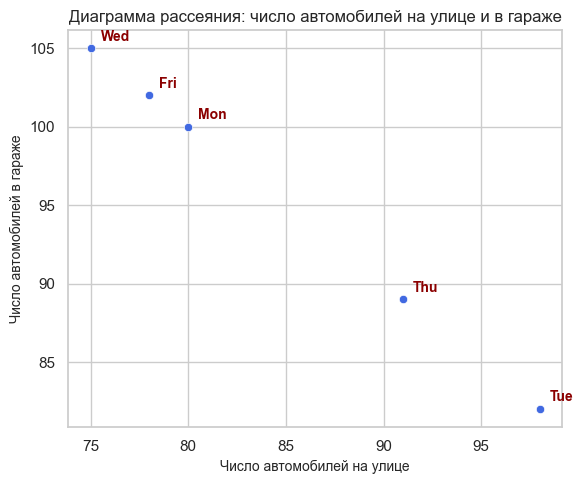

In [6]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="Street", y="Garage", data=df_parking, color="royalblue")

for i, row in df_parking.iterrows():
    plt.text(row["Street"] + 0.5, row["Garage"] + 0.5, row["Day"],
             fontsize=10, color="darkred", weight="bold")
    
plt.title("Диаграмма рассеяния: число автомобилей на улице и в гараже", fontsize = 12)
plt.xlabel("Число автомобилей на улице", fontsize = 10)
plt.ylabel("Число автомобилей в гараже", fontsize = 10)
plt.grid(True)
plt.tight_layout()
plt.show()

## Задание №2 Найти и выгрузить данные. Вывести, провести предобработку и описать признаки.

In [7]:
import kagglehub
import pandas as pd
import os


path = kagglehub.dataset_download("ekibee/car-sales-information")

file_path = os.path.join(path, "all_regions.csv")
df = pd.read_csv(file_path)

#### Первые N строк

In [8]:
n = 5
df.head(n)

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,link,description,parse_date
0,Volkswagen,Golf,Хэтчбек 5 дв.,Серебристый,Бензин,NaN,240000.0,Механика,101.0,280000,NaN,NaN,NaN,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/volkswagen/golf/5001300...,101 л.с. люк не течёт. Документы в порядке. Со...,2023-05-02 01:00:00
1,Лада,1111 Ока,Хэтчбек 3 дв.,Фиолетовый,Бензин,1996.0,37000.0,Механика,33.0,95000,0.6 MT 11113,ВАЗ-11113,0.7 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/oka/50378140.html,"Ваз Ока Год: 2003 Цвет: Баклажан, в ПТС так и ...",2023-05-02 20:00:00
2,Toyota,Funcargo,Хэтчбек 5 дв.,Серебристый,Бензин,2002.0,295000.0,АКПП,87.0,380000,1.3 J,2NZ-FE,1.3 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/toyota/funcargo/5037751...,ХОРОШЕЕ СОСТОЯНИЕ. замена комплекта грм и помп...,2023-05-02 20:00:00
3,Лада,Гранта,Лифтбек,Серый,Бензин,2018.0,16000.0,Механика,106.0,795000,1.6 MT Comfort,ВАЗ-21127,1.6 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/granta/50382492.html,"Автомобиль в отличном техническом состоянии, н...",2023-05-02 23:00:00
4,Лада,Нива Легенд,Джип 3 дв.,Зеленый,Бензин,NaN,NaN,Механика,83.0,1022900,NaN,NaN,NaN,2023-04-02 00:00:00,Яблоновский,https://yablonovskiy.drom.ru/lada/niva_legend/...,Модель: Нива Легенд Комплектация: LADA (ВАЗ) N...,2023-05-02 20:00:00


#### Общая информация о датасете

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294757 entries, 0 to 1294756
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   brand                 1294757 non-null  object 
 1   name                  1294757 non-null  object 
 2   bodyType              1294757 non-null  object 
 3   color                 1257029 non-null  object 
 4   fuelType              1289815 non-null  object 
 5   year                  724644 non-null   float64
 6   mileage               771799 non-null   float64
 7   transmission          1289563 non-null  object 
 8   power                 1273353 non-null  float64
 9   price                 1294757 non-null  int64  
 10  vehicleConfiguration  724647 non-null   object 
 11  engineName            720976 non-null   object 
 12  engineDisplacement    717625 non-null   object 
 13  date                  1294757 non-null  object 
 14  location              1294757 non-

#### Дубликаты

In [10]:
df.duplicated().sum()

np.int64(0)

#### Пустые значения

In [11]:
df.isna().sum()

brand                        0
name                         0
bodyType                     0
color                    37728
fuelType                  4942
year                    570113
mileage                 522958
transmission              5194
power                    21404
price                        0
vehicleConfiguration    570110
engineName              573781
engineDisplacement      577132
date                         0
location                     0
link                         0
description              40352
parse_date                   0
dtype: int64

#### Удаление строк с пустыми значениями

In [12]:
df.dropna(how="any", inplace=True, ignore_index=True)
df.isna().sum()

brand                   0
name                    0
bodyType                0
color                   0
fuelType                0
year                    0
mileage                 0
transmission            0
power                   0
price                   0
vehicleConfiguration    0
engineName              0
engineDisplacement      0
date                    0
location                0
link                    0
description             0
parse_date              0
dtype: int64

#### Число строк и столбцов

In [13]:
df.shape

(399192, 18)

#### Удаление ненужных столбцов, работа над типами данных

In [14]:
df.drop(columns=["link", "parse_date"], inplace=True)
df.head()

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,description
0,Лада,1111 Ока,Хэтчбек 3 дв.,Фиолетовый,Бензин,1996.0,37000.0,Механика,33.0,95000,0.6 MT 11113,ВАЗ-11113,0.7 LTR,2023-04-02 00:00:00,Майкоп,"Ваз Ока Год: 2003 Цвет: Баклажан, в ПТС так и ..."
1,Toyota,Funcargo,Хэтчбек 5 дв.,Серебристый,Бензин,2002.0,295000.0,АКПП,87.0,380000,1.3 J,2NZ-FE,1.3 LTR,2023-04-02 00:00:00,Майкоп,ХОРОШЕЕ СОСТОЯНИЕ. замена комплекта грм и помп...
2,Лада,Гранта,Лифтбек,Серый,Бензин,2018.0,16000.0,Механика,106.0,795000,1.6 MT Comfort,ВАЗ-21127,1.6 LTR,2023-04-02 00:00:00,Майкоп,"Автомобиль в отличном техническом состоянии, н..."
3,Chevrolet,Niva,Джип 5 дв.,Зеленый,Бензин,2002.0,220000.0,Механика,80.0,450000,1.7 MT L,ВАЗ-2123,1.7 LTR,2023-04-03 00:00:00,Майкоп,Продам шевика в хорошем состоянии. Гнили нет о...
4,Лада,2114 Самара,Хэтчбек 5 дв.,Черный,Бензин,2007.0,185000.0,Механика,81.0,120000,1.6 MT 21144-22-010,ВАЗ-11183,1.6 LTR,2023-04-03 00:00:00,Майкоп,"в хорошем состоянии.гнили нет,много чего новог..."


#### Приведение типов данных

In [15]:
df["year"] = df["year"].astype("int64")
df["mileage"] = df["mileage"].astype("int64")
df["power"] = df["power"].astype("int64")
df["engineDisplacement"] = df["engineDisplacement"].str.rstrip("LTR").astype("float64")
df["date"] = df["date"].astype("datetime64[ns]")
df.head()

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,description
0,Лада,1111 Ока,Хэтчбек 3 дв.,Фиолетовый,Бензин,1996,37000,Механика,33,95000,0.6 MT 11113,ВАЗ-11113,0.7,2023-04-02,Майкоп,"Ваз Ока Год: 2003 Цвет: Баклажан, в ПТС так и ..."
1,Toyota,Funcargo,Хэтчбек 5 дв.,Серебристый,Бензин,2002,295000,АКПП,87,380000,1.3 J,2NZ-FE,1.3,2023-04-02,Майкоп,ХОРОШЕЕ СОСТОЯНИЕ. замена комплекта грм и помп...
2,Лада,Гранта,Лифтбек,Серый,Бензин,2018,16000,Механика,106,795000,1.6 MT Comfort,ВАЗ-21127,1.6,2023-04-02,Майкоп,"Автомобиль в отличном техническом состоянии, н..."
3,Chevrolet,Niva,Джип 5 дв.,Зеленый,Бензин,2002,220000,Механика,80,450000,1.7 MT L,ВАЗ-2123,1.7,2023-04-03,Майкоп,Продам шевика в хорошем состоянии. Гнили нет о...
4,Лада,2114 Самара,Хэтчбек 5 дв.,Черный,Бензин,2007,185000,Механика,81,120000,1.6 MT 21144-22-010,ВАЗ-11183,1.6,2023-04-03,Майкоп,"в хорошем состоянии.гнили нет,много чего новог..."


#### Общая информация о датасете после предобработки

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399192 entries, 0 to 399191
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   brand                 399192 non-null  object        
 1   name                  399192 non-null  object        
 2   bodyType              399192 non-null  object        
 3   color                 399192 non-null  object        
 4   fuelType              399192 non-null  object        
 5   year                  399192 non-null  int64         
 6   mileage               399192 non-null  int64         
 7   transmission          399192 non-null  object        
 8   power                 399192 non-null  int64         
 9   price                 399192 non-null  int64         
 10  vehicleConfiguration  399192 non-null  object        
 11  engineName            399192 non-null  object        
 12  engineDisplacement    399192 non-null  float64       
 13 

### Задание 2.1 Построить корреляционную матрицу по одной целевой переменной. Определить наиболее коррелирующую переменную, продолжить с ней работу в следующем пункте.


Корреляционная матрица

In [17]:
target_col = 'price'

if target_col not in df.columns:
    raise ValueError(f"Целевая переменная '{target_col}' не найдена. Проверь название столбца в DataFrame.")

corr_matrix = df.corr(numeric_only=True)
corr_matrix.style.background_gradient(cmap="coolwarm")

,year,mileage,power,price,engineDisplacement
year,1.000000,-0.514805,0.171553,0.489916,-0.010728
mileage,-0.514805,1.000000,0.012477,-0.362176,0.119452
power,0.171553,0.012477,1.000000,0.569977,0.849239
price,0.489916,-0.362176,0.569977,1.000000,0.426155
engineDisplacement,-0.010728,0.119452,0.849239,0.426155,1.000000


Визуализируем корреляционную матрицу по одной целевой переменной price

In [18]:
corr_price = df.corr(numeric_only=True).price.to_frame()
corr_price.style.background_gradient(cmap="coolwarm")

,price
year,0.489916
mileage,-0.362176
power,0.569977
price,1.000000
engineDisplacement,0.426155


### Задание 2.2 Реализовать регрессию вручную, отобразить наклон, сдвиг и MSE.

Реализация с моделью LinearRegression

In [19]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()
X = df["power"].values.reshape(-1, 1)
y = df["price"].values.reshape(-1, 1)

model.fit(X, y)
model.coef_, model.intercept_

(array([[11905.52839435]]), array([-547104.41923835]))

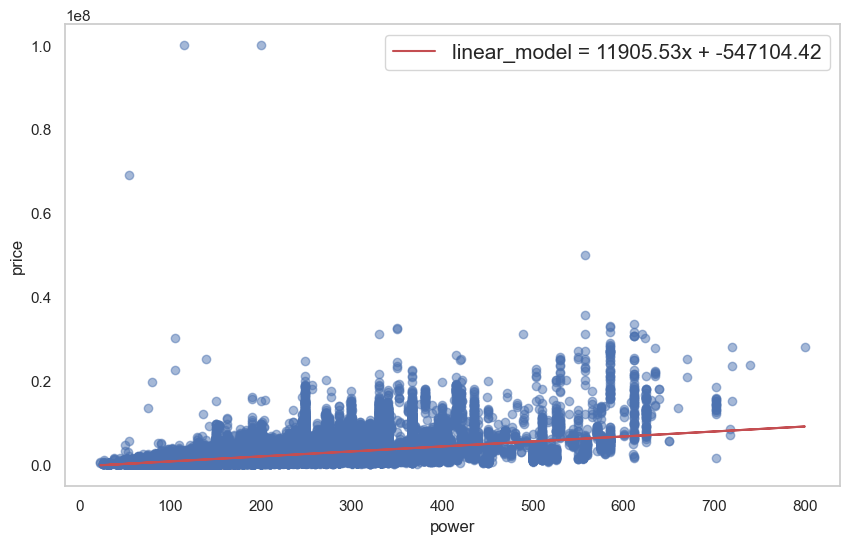

In [20]:
k = model.coef_[0][0]
b = model.intercept_[0]
model_sklearn = k * X + b

fig = plt.figure(figsize=(10,6))
plt.plot(X, model_sklearn, color = "r", label = f"linear_model = {k:.2f}x + {b:.2f}")
plt.scatter(X, y, alpha=0.5)
plt.grid()
plt.xlabel("power")
plt.ylabel("price")
plt.legend(prop={"size": 15})
plt.show()

Средняя квадратичная ошибка

In [21]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y, model.predict(X))

1303173377786.6855

Ручная реализация

In [22]:
def gradient_descent(X, y, lr=0.001, eps=1e-10, max_iter=10000):
    """
    Реализация градиентного спуска для линейной регрессии
    """
    X_mean, X_std = np.mean(X), np.std(X)
    y_mean, y_std = np.mean(y), np.std(y)
    
    X_normalized = (X - X_mean) / X_std
    y_normalized = (y - y_mean) / y_std
    
    k = 0
    b = 0
    n = len(y_normalized)
    
    prev_loss = None
    
    for i in range(max_iter):
        y_pred = k * X_normalized + b
        
        loss = np.mean((y_normalized - y_pred) ** 2)
        
        grad_k = (-2/n) * np.sum((y_normalized - y_pred) * X_normalized)
        grad_b = (-2/n) * np.sum(y_normalized - y_pred)
        
        k -= lr * grad_k
        b -= lr * grad_b
        
        if prev_loss is not None and abs(prev_loss - loss) < eps:
            print(f"Сходимость достигнута на итерации {i}")
            break
            
        prev_loss = loss
        
        if i % 1000 == 0:
            print(f"Iteration {i}, Loss: {loss:.6f}")
            
    k_original = k * (y_std / X_std)
    b_original = b * y_std + y_mean - k * (y_std / X_std) * X_mean
    
    return k_original, b_original

In [23]:
k_original, b_original = gradient_descent(X, y)
gradient_descent_model = k_original * X + b_original

Iteration 0, Loss: 1.000000
Iteration 1000, Loss: 0.681052
Iteration 2000, Loss: 0.675234
Iteration 3000, Loss: 0.675128
Iteration 4000, Loss: 0.675126
Сходимость достигнута на итерации 4092


Полученные коэффициенты

In [24]:
print(f"k = {k_original}")
print(f"b = {b_original}")

k = 11902.239467874884
b = -546643.4312317397


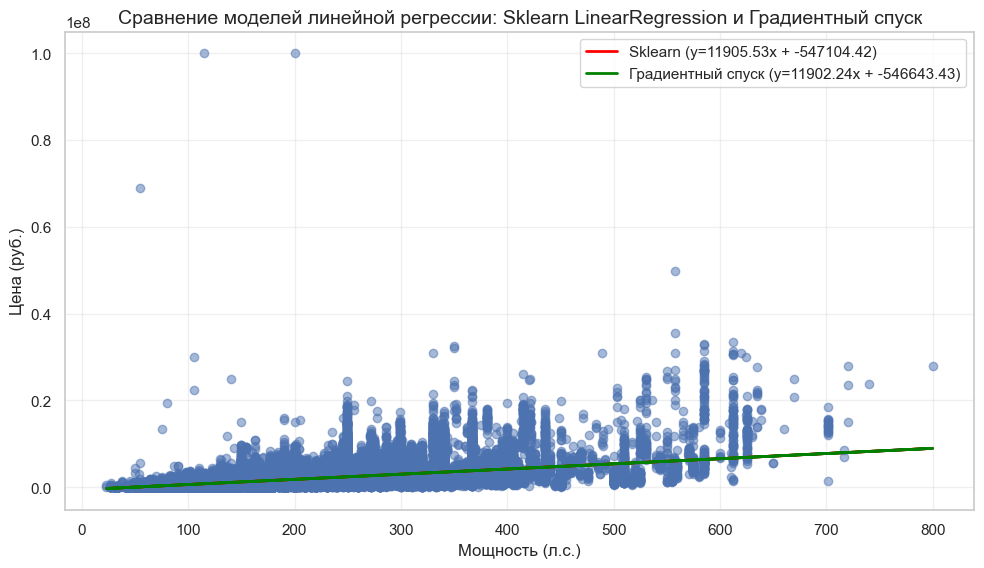

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(X, y, alpha=0.5)

plt.plot(X, model_sklearn, color='red', linewidth=2, 
         label=f'Sklearn (y={model.coef_[0][0]:.2f}x + {model.intercept_[0]:.2f})')

plt.plot(X, gradient_descent_model, color='green', linewidth=2,
         label=f'Градиентный спуск (y={k_original:.2f}x + {b_original:.2f})')

plt.xlabel('Мощность (л.с.)', fontsize=12)
plt.ylabel('Цена (руб.)', fontsize=12)
plt.title('Сравнение моделей линейной регрессии: Sklearn LinearRegression и Градиентный спуск', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Задание №3 Загрузить данные: "insurance.csv". Вывести и провести предобработку. Вывести список уникальных регионов.


In [26]:
import os
insurance_path = "insurance.csv"

if not os.path.exists(insurance_path):
    raise FileNotFoundError(
        "Файл 'insurance.csv' не найден в текущей директории. "
        "Положите 'insurance.csv' в рабочую папку ноутбука и перезапустите ячейку."
    )

df_ins = pd.read_csv(insurance_path)
df_ins.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [27]:
df_ins.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [30]:
print("Shape:", df_ins.shape)
print("Нулевые значения в каждом столбце:\n", df_ins.isnull().sum())
print("Уникальные регионы:", df_ins['region'].unique())

Shape: (1338, 7)
Нулевые значения в каждом столбце:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Уникальные регионы: ['southwest' 'southeast' 'northwest' 'northeast']


### Задание 3.1 Выполнить однофакторный ANOVA тест, чтобы проверить влияние региона на индекс массы тела (BMI), используя первый способ, через библиотеку Scipy.

При формировании групп для сравнения в однофакторном дисперсионном
анализе используется только одна переменная (фактор). 

Нулевая гипотеза: Средние BMI во всех регионах одинаковы (регион не влияет на BMI)

In [33]:
groups = [group["bmi"].values for _, group in df_ins.groupby("region")]
f_stat, pval = stats.f_oneway(*groups)
print(f"ANOVA (scipy) region -> BMI: F = {f_stat:.4f}, p-value = {pval:.6f}")

ANOVA (scipy) region -> BMI: F = 39.4951, p-value = 0.000000


Так как p-value < 0.05, нулевая гипотеза отвергается, значит средние значения BMI значимо различаются между регионами. Регион влияет на индекс массы тела.

### Задание 3.2 Выполнить однофакторный ANOVA тест, чтобы проверить влияние региона на индекс массы тела (BMI), используя второй способ, с помощью функции anova_lm() из библиотеки statsmodels.

In [36]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols("bmi ~ region", data=df_ins).fit()
anova_table = anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
region,4055.880631,3.0,39.495057,1.881839e-24
Residual,45664.319755,1334.0,NaN,NaN


Sum of Squares — сумма квадратов отклонений

Degrees of Freedom — степени свободы (сколько независимых значений участвует в оценке)

F-statistic — отношение межгрупповой дисперсии к внутригрупповой

p-value — вероятность получить такое (или большее) значение F при H0 (если < 0.05 — различия значимы)

### Задание 3.3 С помощью t критерия Стьюдента перебрать все пары. Определить поправку Бонферрони. Сделать выводы.


In [ ]:
from itertools import combinations

regions = df_ins['region'].unique()
pairs = list(combinations(regions, 2))
alpha = 0.05
m = len(pairs)
alpha_bonf = alpha / m

results = []
for a, b in pairs:
    a_vals = df_ins[df_ins['region'] == a]['bmi']
    b_vals = df_ins[df_ins['region'] == b]['bmi']
    t, p = stats.ttest_ind(a_vals, b_vals, equal_var=False)
    results.append((a, b, t, p, p < alpha_bonf))

res_df = pd.DataFrame(results, columns=["region_a","region_b","t","p","reject_H0_after_Bonf"])
res_df_sorted = res_df.sort_values("p")
res_df_sorted

,region_a,region_b,t,p,reject_H0_after_Bonf
3,southeast,northwest,9.376833,9.989831e-20,True
4,southeast,northeast,8.835471,8.311733e-18,True
0,southwest,southeast,-5.951605,4.233221e-09,True
1,southwest,northwest,3.284417,1.077543e-03,True
2,southwest,northeast,3.116697,1.910080e-03,True
5,northwest,northeast,0.060294,9.519402e-01,False


### Задание 3.4 Выполнить пост-хок тесты Тьюки и построить график.

In [38]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_ins['bmi'], groups=df_ins['region'], alpha=0.05)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
northeast,northwest,0.0263,0.9999,-1.1552,1.2078,False
northeast,southeast,4.1825,0.0,3.033,5.332,True
northeast,southwest,1.4231,0.0107,0.2416,2.6046,True
northwest,southeast,4.1562,0.0,3.0077,5.3047,True
northwest,southwest,1.3968,0.0127,0.2162,2.5774,True
southeast,southwest,-2.7594,0.0,-3.9079,-1.6108,True


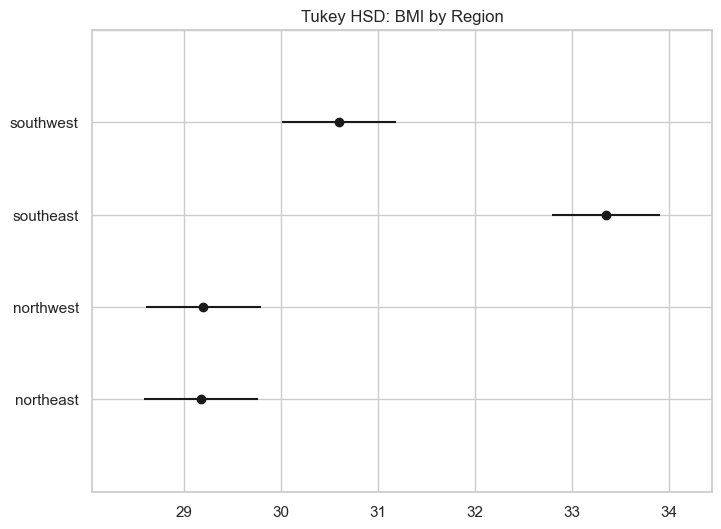

In [39]:
fig = tukey.plot_simultaneous(figsize=(8,6))
plt.title("Tukey HSD: BMI by Region")
plt.show()

### Задание 3.5 Выполнить двухфакторный ANOVA тест, чтобы проверить влияние региона и пола на индекс массы тела (BMI), используя функцию anova_lm() из библиотеки statsmodels.

In [40]:
model2 = ols("bmi ~ region * sex", data=df_ins).fit()
anova_table2 = anova_lm(model2, typ=2)
anova_table2

,sum_sq,df,F,PR(>F)
region,4034.975135,3.0,39.398134,2.163195e-24
sex,86.007035,1.0,2.519359,1.126940e-01
region:sex,174.157808,3.0,1.700504,1.650655e-01
Residual,45404.154911,1330.0,NaN,NaN
